In [1]:
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_PATH = REPO_ROOT / "data" / "processed" / "dataset.csv"

dataset = pd.read_csv(DATASET_PATH, parse_dates = ["date_parsed"])
print(dataset.shape)
print(dataset.columns.tolist())
dataset.head()

(273, 27)
['ticker', 'quarter', 'date_parsed', 'word_count', 'sentence_count', 'avg_sentence_length', 'flesch_kincaid_grade', 'numeric_density', 'negative_count', 'uncertainty_count', 'litigious_count', 'forward_looking_count', 'word_count_zscore', 'sentence_count_zscore', 'avg_sentence_length_zscore', 'flesch_kincaid_grade_zscore', 'numeric_density_zscore', 'negative_count_zscore', 'uncertainty_count_zscore', 'litigious_count_zscore', 'forward_looking_count_zscore', 'excess_return_1d', 'excess_return_3d', 'excess_return_5d', 'y_1d', 'y_3d', 'y_5d']


,ticker,quarter,date_parsed,word_count,sentence_count,avg_sentence_length,flesch_kincaid_grade,numeric_density,negative_count,uncertainty_count,...,negative_count_zscore,uncertainty_count_zscore,litigious_count_zscore,forward_looking_count_zscore,excess_return_1d,excess_return_3d,excess_return_5d,y_1d,y_3d,y_5d
0,AAPL,2019-Q3,2019-07-30,8355,440,18.988636,10.239787,26.211849,18,30,...,-1.932399,-2.063308,-0.402183,1.347831,0.031345,0.004137,-0.013460,0,0,1
1,AAPL,2020-Q1,2020-01-28,8267,459,18.010893,10.009808,24.434499,27,38,...,-1.268959,-1.506463,-0.402183,1.347831,0.021758,-0.009963,-0.002987,0,1,0
2,AAPL,2020-Q2,2020-04-30,8278,442,18.728507,10.225606,16.791496,51,55,...,0.500212,-0.323169,-1.653419,1.609909,0.010374,0.027566,0.043472,0,0,0
3,AAPL,2020-Q3,2020-07-30,8109,468,17.326923,9.551080,21.211000,36,66,...,-0.605520,0.442493,1.474671,0.386877,0.096787,0.121258,0.152131,0,0,0
4,AAPL,2020-Q4,2020-10-29,8970,494,18.157895,9.559400,19.175028,40,49,...,-0.310658,-0.740802,0.849053,0.299518,-0.045593,-0.060651,-0.029227,1,1,1


In [ ]:
# cell 1

print(f"Date range: {dataset['date_parsed'].min()} to {dataset['date_parsed'].max()}")
print(f"\nRows per year:")
print(dataset['date_parsed'].dt.year.value_counts().sort_index())
print(f"\nRows per quarter (first/last 5):")
quarters = dataset['date_parsed'].dt.to_period('Q').value_counts().sort_index()
print(quarters.head())
print("...")
print(quarters.tail())

Date range: 2019-06-25 00:00:00 to 2023-02-02 00:00:00

Rows per year:
date_parsed
2019     14
2020     20
2021    111
2022    112
2023     16
Name: count, dtype: int64

Rows per quarter (first/last 5):
date_parsed
2019Q2    1
2019Q3    8
2019Q4    5
2020Q1    7
2020Q2    6
Freq: Q-DEC, Name: count, dtype: int64
...
date_parsed
2022Q1    29
2022Q2    26
2022Q3    29
2022Q4    28
2023Q1    16
Freq: Q-DEC, Name: count, dtype: int64


In [ ]:
# cell 2 - time based splitting

TRAIN_END = pd.Timestamp("2022-08-01")
VAL_END = pd.Timestamp("2022-10-01")

train_df = dataset[dataset["date_parsed"] < TRAIN_END].copy()
val_df = dataset[(dataset["date_parsed"] >= TRAIN_END) & (dataset["date_parsed"] < VAL_END)].copy()
test_df = dataset[dataset["date_parsed"] >= VAL_END].copy()

# sanity check
assert len(train_df) + len(val_df) + len(test_df) == 273
assert train_df["date_parsed"].max() < val_df["date_parsed"].min()
assert val_df["date_parsed"].max() < test_df["date_parsed"].min()

print(f"Train: {len(train_df)} rows  ({train_df['date_parsed'].min().date()} to {train_df['date_parsed'].max().date()})")
print(f"Val:   {len(val_df)} rows  ({val_df['date_parsed'].min().date()} to {val_df['date_parsed'].max().date()})")
print(f"Test:  {len(test_df)} rows  ({test_df['date_parsed'].min().date()} to {test_df['date_parsed'].max().date()})")

Train: 218 rows  (2019-06-25 to 2022-07-29)
Val:   11 rows  (2022-08-02 to 2022-09-22)
Test:  44 rows  (2022-10-14 to 2023-02-02)


In [4]:
# Cell 2b — Class balance per split (across all 3 windows)
print("Class balance (% of rows with y=1, i.e., 'high-risk'):\n")
print(f"{'Split':<8} {'y_1d':>8} {'y_3d':>8} {'y_5d':>8}")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    y1 = df["y_1d"].mean() * 100
    y3 = df["y_3d"].mean() * 100
    y5 = df["y_5d"].mean() * 100
    print(f"{name:<8} {y1:>7.1f}% {y3:>7.1f}% {y5:>7.1f}%")

Class balance (% of rows with y=1, i.e., 'high-risk'):

Split        y_1d     y_3d     y_5d
Train       50.0%    50.9%    50.0%
Val         36.4%    45.5%    36.4%
Test        52.3%    45.5%    52.3%


In [5]:
# Cell 2c — Ticker coverage per split
train_tickers = set(train_df["ticker"])
val_tickers = set(val_df["ticker"])
test_tickers = set(test_df["ticker"])

print(f"Tickers in train: {len(train_tickers)} / 30")
print(f"Tickers in val:   {len(val_tickers)} / 30")
print(f"Tickers in test:  {len(test_tickers)} / 30")

# Tickers missing from some splits
only_train = train_tickers - val_tickers - test_tickers
missing_from_train = (val_tickers | test_tickers) - train_tickers

if only_train:
    print(f"\nTickers ONLY in train (model never tested on these): {sorted(only_train)}")
if missing_from_train:
    print(f"\nTickers in val/test but NOT in train (model has no baseline): {sorted(missing_from_train)}")

Tickers in train: 30 / 30
Tickers in val:   11 / 30
Tickers in test:  28 / 30

Tickers ONLY in train (model never tested on these): ['ETSY', 'META']


In [6]:
# Cell 2d — Feature drift between train and test
RAW_FEATURES = [
    "word_count", "sentence_count", "avg_sentence_length",
    "flesch_kincaid_grade", "numeric_density",
    "negative_count", "uncertainty_count", "litigious_count",
    "forward_looking_count",
]

print("Feature mean drift (test mean − train mean), all 9 raw features:\n")

drifts = {}
for col in RAW_FEATURES:
    train_mean = train_df[col].mean()
    test_mean = test_df[col].mean()
    train_std = train_df[col].std()
    drift_in_stds = (test_mean - train_mean) / train_std if train_std > 0 else 0
    drifts[col] = drift_in_stds

# Sort by magnitude of drift (largest first)
sorted_drifts = sorted(drifts.items(), key=lambda x: abs(x[1]), reverse=True)

print(f"{'Feature':<25} {'Train mean':>12} {'Test mean':>12} {'Drift (stds)':>15}")
print("-" * 70)
for col, drift in sorted_drifts:
    train_mean = train_df[col].mean()
    test_mean = test_df[col].mean()
    print(f"{col:<25} {train_mean:>12.2f} {test_mean:>12.2f} {drift:>+15.2f}")

Feature mean drift (test mean − train mean), all 9 raw features:

Feature                     Train mean    Test mean    Drift (stds)
----------------------------------------------------------------------
word_count                     9660.90      9258.57           -0.23
avg_sentence_length              17.91        17.47           -0.21
litigious_count                   7.06         5.70           -0.18
flesch_kincaid_grade              9.91         9.73           -0.16
sentence_count                  543.87       533.39           -0.10
negative_count                   46.74        48.30           +0.07
forward_looking_count            78.20        79.50           +0.04
uncertainty_count                72.45        71.70           -0.03
numeric_density                  20.73        20.82           +0.01


In [ ]:
# cell 3 - Defining X and y for train, val and test across all 3 windows

# independent variables
RAW_FEATURES = ["word_count", "sentence_count", "avg_sentence_length", 
                "flesch_kincaid_grade", "numeric_density", "negative_count", 
                "uncertainty_count", "litigious_count", "forward_looking_count"]
ZSCORE_FEATURES = [f"{c}_zscore" for c in RAW_FEATURES]
FEATURE_COLS = RAW_FEATURES + ZSCORE_FEATURES

# target variables 
TARGET_COLS = ["y_1d", "y_3d", "y_5d"]

X_train = train_df[FEATURE_COLS].copy()
X_val = val_df[FEATURE_COLS].copy()
X_test = test_df[FEATURE_COLS].copy()

y_train = {w: train_df[w].copy() for w in TARGET_COLS}
y_val = {w: val_df[w].copy() for w in TARGET_COLS}
y_test = {w: test_df[w].copy() for w in TARGET_COLS}

print("Feature matrix shapes:")
print(f" X_train: {X_train.shape}")
print(f" X_val: {X_val.shape}")
print(f" X_test: {X_test.shape}")

print("\nTarget vector shapes (same across all 3 windows):")
print(f" y_train: {y_train['y_5d'].shape}")
print(f" y_val: {y_val['y_5d'].shape}")
print(f" y_test: {y_test['y_5d'].shape}")

print(f"\nFeature count: {len(FEATURE_COLS)} ({len(RAW_FEATURES)} raw + {len(ZSCORE_FEATURES)} z-scored)")
print(f"Sample features: {FEATURE_COLS[:3]} ... {FEATURE_COLS[-3:]}")

# sanity check
assert X_train.shape == (218, 18)
assert X_val.shape == (11, 18)
assert X_test.shape == (44, 18)
assert not X_train.isnull().any().any(), "X_train has nulls!"
assert not X_val.isnull().any().any(), "X_val has nulls!"
assert not X_test.isnull().any().any(), "X_test has nulls!"
print("\n All shape and null checks passed")

Feature matrix shapes:
 X_train: (218, 18)
 X_val: (11, 18)
 X_test: (44, 18)

Target vector shapes (same across all 3 windows):
 y_train: (218,)
 y_val: (11,)
 y_test: (44,)

Feature count: 18 (9 raw + 9 z-scored)
Sample features: ['word_count', 'sentence_count', 'avg_sentence_length'] ... ['uncertainty_count_zscore', 'litigious_count_zscore', 'forward_looking_count_zscore']

 All shape and null checks passed


In [ ]:
# cell 4 - Logistic regression for baseline

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# standardizing training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# training 1 log reg per window
baseline_results = {}

for window in TARGET_COLS:
    model = LogisticRegression(max_iter = 1000, random_state = 42)
    model.fit(X_train_scaled, y_train[window])

    train_pred = model.predict_proba(X_train_scaled)[:, 1]
    val_pred = model.predict_proba(X_val_scaled)[:, 1]

    train_auc = roc_auc_score(y_train[window], train_pred)
    val_auc = roc_auc_score(y_val[window], val_pred)

    baseline_results[window] = {"train_auc": train_auc,
                                "val_auc": val_auc,
                                "gap": train_auc - val_auc}
    
print("Logistic Regression Baseline\n")
print(f"{'Window': <8} {'Train AUC': >12} {'Val AUC': >12} {'Gap': >8}")
print("-" * 44)
for window, r in baseline_results.items():
    print(f"{window: <8} {r['train_auc']: >12.3f} {r['val_auc']: >12.3f} {r['gap']: >+8.3f}")

Logistic Regression Baseline

Window      Train AUC      Val AUC      Gap
--------------------------------------------
y_1d            0.693        0.679   +0.014
y_3d            0.676        0.533   +0.143
y_5d            0.685        0.429   +0.257


In [9]:
# Sanity check — what is the model actually predicting on val?
window = "y_5d"
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train[window])
val_pred = model.predict_proba(X_val_scaled)[:, 1]

print(f"Val predictions for {window}:")
for true_label, pred_prob in zip(y_val[window].values, val_pred):
    print(f"  True={true_label}, Predicted prob of class 1={pred_prob:.3f}")

Val predictions for y_5d:
  True=1, Predicted prob of class 1=0.519
  True=0, Predicted prob of class 1=0.355
  True=0, Predicted prob of class 1=0.782
  True=0, Predicted prob of class 1=0.606
  True=0, Predicted prob of class 1=0.456
  True=1, Predicted prob of class 1=0.466
  True=1, Predicted prob of class 1=0.324
  True=1, Predicted prob of class 1=0.567
  True=0, Predicted prob of class 1=0.394
  True=0, Predicted prob of class 1=0.406
  True=0, Predicted prob of class 1=0.711


# XGBoost Training

## Goal
Train one XGBoost classifier per window (y_1d, y_3d, y_5d). Beat the logistic regression baseline. Report all three windows transparently rather than picking a winner by val AUC alone (val is too small at 11 rows for reliable single-number selection).

## Baselines to beat

| Window | Logistic val AUC |
|---|---|
| y_1d | 0.679 |
| y_3d | 0.533 |
| y_5d | 0.429 |

XGBoost should clearly improve on these — though val is noisy, so we'll use train AUC + val AUC + train-val gap *together* to assess each model.

In [ ]:
# cell 5 - xgboost training on all 3 windows (1, 3, 5)

from xgboost import XGBClassifier

XGB_PARAMS = {"n_estimators": 100, "max_depth": 3, 
              "learning_rate": 0.1, "random_state": 42, 
              "eval_metric": "auc", "n_jobs": -1} 

xgb_results = {}

for window in TARGET_COLS:
    model = XGBClassifier(**XGB_PARAMS)
    model.fit(X_train, y_train[window])

    train_pred = model.predict_proba(X_train)[:, 1]
    val_pred = model.predict_proba(X_val)[:, 1]

    train_auc = roc_auc_score(y_train[window], train_pred)
    val_auc = roc_auc_score(y_val[window], val_pred)

    xgb_results[window] = {"model": model, "train_auc": train_auc, 
                           "val_auc": val_auc, "gap": train_auc - val_auc}
    
print("XGBoost vs Logictic Regression Baseline\n")
print(f"{'Window': <8} {'LR Val': >10} {'XGB Train': >12} {'XGB Val': >10} {'XGB Gap': >10} {'XGB vs LR': >14}")
print("-" * 70)
for window in TARGET_COLS:
    lr_val = baseline_results[window]["val_auc"]
    xgb_train = xgb_results[window]["train_auc"]
    xgb_val = xgb_results[window]["val_auc"]
    xgb_gap = xgb_results[window]["gap"]
    delta = xgb_val - lr_val
    print(f"{window:<8} {lr_val:>10.3f} {xgb_train:>12.3f} {xgb_val:>10.3f} {xgb_gap:>+10.3f} {delta:>+14.3f}")

XGBoost vs Logictic Regression Baseline

Window       LR Val    XGB Train    XGB Val    XGB Gap      XGB vs LR
----------------------------------------------------------------------
y_1d          0.679        1.000      0.571     +0.429         -0.107
y_3d          0.533        1.000      0.400     +0.600         -0.133
y_5d          0.429        1.000      0.500     +0.500         +0.071


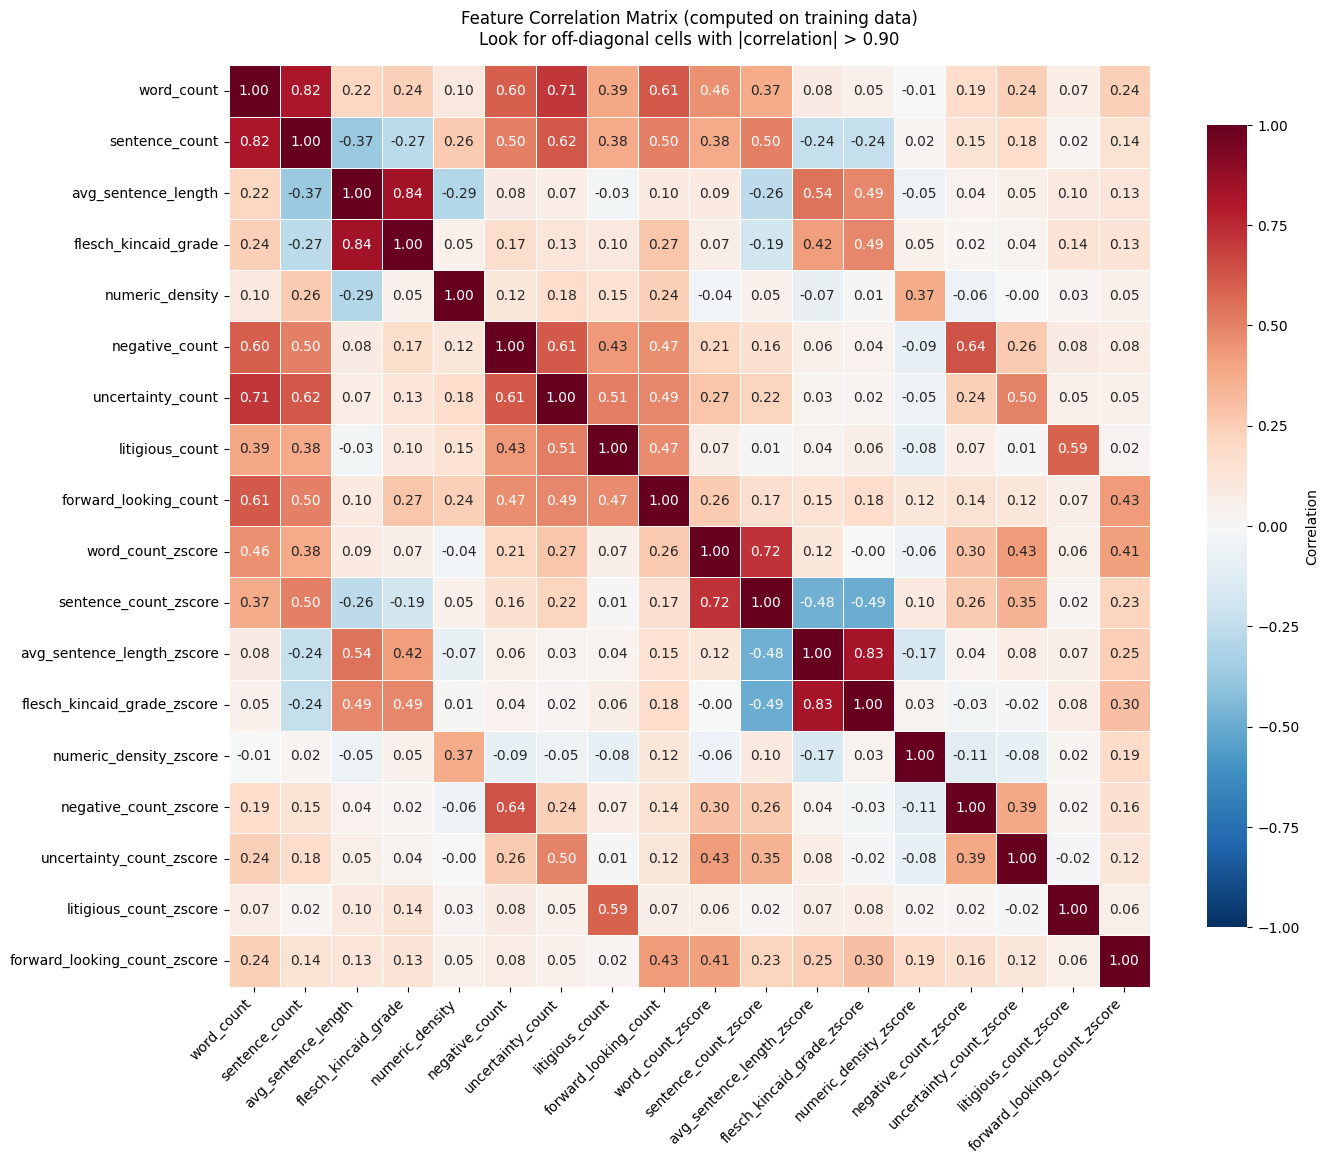


Feature pairs with |correlation| > 0.85 (excluding self-pairs):

  No pairs above 0.85 threshold — features appear independent


In [ ]:
# cell 6 - Correlation heatmap of all 18 features (computed on training data only)
import seaborn as sns
import matplotlib.pyplot as plt

# Use training data only — never compute statistics on val/test
corr_matrix = X_train.corr()

# Set up the figure
plt.figure(figsize=(14, 12))

# Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,           # show correlation values in each cell
    fmt=".2f",            # 2 decimal places
    cmap="RdBu_r",        # red = positive, blue = negative correlation
    center=0,             # color scale centered at 0
    vmin=-1, vmax=1,      # full correlation range
    square=True,          # square cells
    linewidths=0.5,       # thin gridlines
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
)

plt.title("Feature Correlation Matrix (computed on training data)\n"
          "Look for off-diagonal cells with |correlation| > 0.90", 
          fontsize=12, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Programmatic extraction of high-correlation pairs (excluding self-correlation)
print("\nFeature pairs with |correlation| > 0.85 (excluding self-pairs):\n")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.85:
            high_corr_pairs.append((col_i, col_j, corr_val))

if high_corr_pairs:
    high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    print(f"{'Feature 1':<30} {'Feature 2':<30} {'Correlation':>12}")
    print("-" * 75)
    for f1, f2, c in high_corr_pairs:
        print(f"{f1:<30} {f2:<30} {c:>+12.3f}")
else:
    print("  No pairs above 0.85 threshold — features appear independent")

Train data sorted by date: 2019-06-25 → 2022-07-29
Train shape: (218, 18)

Fold 1: Train= 38 rows (2019-06-25 → 2021-01-26)  Val= 36 rows (2021-01-26 → 2021-04-29)
Fold 2: Train= 74 rows (2019-06-25 → 2021-04-29)  Val= 36 rows (2021-04-29 → 2021-08-17)
Fold 3: Train=110 rows (2019-06-25 → 2021-08-17)  Val= 36 rows (2021-08-18 → 2022-01-19)
Fold 4: Train=146 rows (2019-06-25 → 2022-01-19)  Val= 36 rows (2022-01-20 → 2022-04-26)
Fold 5: Train=182 rows (2019-06-25 → 2022-04-26)  Val= 36 rows (2022-04-27 → 2022-07-29)


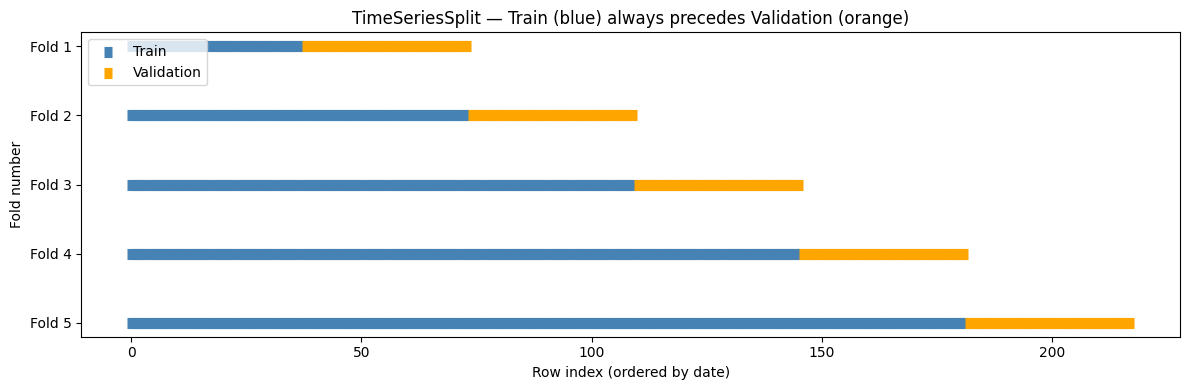

In [12]:
# Cell 7 — TimeSeriesSplit setup + visualization
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Ensure train data is sorted by date (it should already be from filtering, but defensive)
train_df_sorted = train_df.sort_values("date_parsed").reset_index(drop=True)
X_train_sorted = train_df_sorted[FEATURE_COLS].copy()
y_train_sorted = {w: train_df_sorted[w].copy() for w in TARGET_COLS}

# Confirm sort is correct
assert train_df_sorted["date_parsed"].is_monotonic_increasing, "Train dates not sorted!"
print(f"Train data sorted by date: {train_df_sorted['date_parsed'].min().date()} → {train_df_sorted['date_parsed'].max().date()}")
print(f"Train shape: {X_train_sorted.shape}\n")

# Set up 5-fold TimeSeriesSplit
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Visualize the folds
fig, ax = plt.subplots(figsize=(12, 4))

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_sorted)):
    # Plot train indices
    ax.scatter(train_idx, [fold_idx] * len(train_idx), 
               c="steelblue", marker="_", lw=8, label="Train" if fold_idx == 0 else "")
    # Plot val indices
    ax.scatter(val_idx, [fold_idx] * len(val_idx), 
               c="orange", marker="_", lw=8, label="Validation" if fold_idx == 0 else "")
    
    # Print fold details
    train_start_date = train_df_sorted.iloc[train_idx[0]]["date_parsed"].date()
    train_end_date = train_df_sorted.iloc[train_idx[-1]]["date_parsed"].date()
    val_start_date = train_df_sorted.iloc[val_idx[0]]["date_parsed"].date()
    val_end_date = train_df_sorted.iloc[val_idx[-1]]["date_parsed"].date()
    print(f"Fold {fold_idx + 1}: "
          f"Train={len(train_idx):3d} rows ({train_start_date} → {train_end_date})  "
          f"Val={len(val_idx):3d} rows ({val_start_date} → {val_end_date})")

ax.set_xlabel("Row index (ordered by date)")
ax.set_ylabel("Fold number")
ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)])
ax.set_title("TimeSeriesSplit — Train (blue) always precedes Validation (orange)")
ax.legend(loc="upper left")
ax.invert_yaxis()  # fold 1 at top
plt.tight_layout()
plt.show()


In [13]:
# Cell 8 — Cross-validated XGBoost hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import time

# Hyperparameter search space
XGB_PARAM_GRID = {
    "n_estimators": [30, 50, 100],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_child_weight": [1, 5, 10],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1, 2, 5],
}

# Fixed parameters (not tuned — these are reliable regularization defaults)
XGB_FIXED_PARAMS = {
    "subsample": 0.8,           # Each tree sees 80% of rows
    "colsample_bytree": 0.8,    # Each tree sees 80% of features
    "random_state": 42,
    "eval_metric": "auc",
    "n_jobs": 1,                # Single-thread per model; parallelism happens at search level
}

# Run randomized search for each window
xgb_tuned_results = {}
N_ITER = 50  # number of random hyperparameter combinations to try

for window in TARGET_COLS:
    print(f"\n{'=' * 60}")
    print(f"Tuning XGBoost for {window}")
    print(f"{'=' * 60}")
    
    base_model = XGBClassifier(**XGB_FIXED_PARAMS)
    
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=XGB_PARAM_GRID,
        n_iter=N_ITER,
        scoring="roc_auc",
        cv=tscv,                   # our TimeSeriesSplit from Cell 7
        random_state=42,
        n_jobs=-1,                 # parallelize across hyperparameter combinations
        verbose=0,
        return_train_score=True,
    )
    
    start_time = time.time()
    search.fit(X_train_sorted, y_train_sorted[window])
    elapsed = time.time() - start_time
    
    # Best configuration
    best_params = search.best_params_
    best_cv_score = search.best_score_
    
    # Refit best model and evaluate on val (the original 11-row val set)
    best_model = search.best_estimator_
    train_pred = best_model.predict_proba(X_train_sorted)[:, 1]
    val_pred = best_model.predict_proba(X_val)[:, 1]
    train_auc = roc_auc_score(y_train_sorted[window], train_pred)
    val_auc = roc_auc_score(y_val[window], val_pred)
    
    # Get the corresponding train CV score (mean across folds)
    best_idx = search.best_index_
    mean_cv_train_auc = search.cv_results_["mean_train_score"][best_idx]
    cv_std = search.cv_results_["std_test_score"][best_idx]
    
    xgb_tuned_results[window] = {
        "best_params": best_params,
        "mean_cv_val_auc": best_cv_score,
        "mean_cv_train_auc": mean_cv_train_auc,
        "cv_std": cv_std,
        "train_auc_full": train_auc,
        "val_auc_holdout": val_auc,
        "model": best_model,
        "search_object": search,
    }
    
    print(f"\nElapsed: {elapsed:.1f}s")
    print(f"\nBest hyperparameters:")
    for k, v in sorted(best_params.items()):
        print(f"  {k}: {v}")
    print(f"\nResults:")
    print(f"  Mean CV train AUC:  {mean_cv_train_auc:.3f}")
    print(f"  Mean CV val AUC:    {best_cv_score:.3f}  (std: {cv_std:.3f})")
    print(f"  CV gap:             {mean_cv_train_auc - best_cv_score:+.3f}")
    print(f"  Full train AUC:     {train_auc:.3f}  (refit on all 218 train rows)")
    print(f"  Holdout val AUC:    {val_auc:.3f}  (on the 11-row val_df)")


Tuning XGBoost for y_1d

Elapsed: 9.8s

Best hyperparameters:
  learning_rate: 0.01
  max_depth: 3
  min_child_weight: 1
  n_estimators: 30
  reg_alpha: 0
  reg_lambda: 1

Results:
  Mean CV train AUC:  0.960
  Mean CV val AUC:    0.548  (std: 0.043)
  CV gap:             +0.412
  Full train AUC:     0.920  (refit on all 218 train rows)
  Holdout val AUC:    0.464  (on the 11-row val_df)

Tuning XGBoost for y_3d

Elapsed: 1.2s

Best hyperparameters:
  learning_rate: 0.1
  max_depth: 3
  min_child_weight: 1
  n_estimators: 100
  reg_alpha: 0
  reg_lambda: 5

Results:
  Mean CV train AUC:  1.000
  Mean CV val AUC:    0.576  (std: 0.057)
  CV gap:             +0.424
  Full train AUC:     0.998  (refit on all 218 train rows)
  Holdout val AUC:    0.467  (on the 11-row val_df)

Tuning XGBoost for y_5d

Elapsed: 1.3s

Best hyperparameters:
  learning_rate: 0.05
  max_depth: 3
  min_child_weight: 5
  n_estimators: 100
  reg_alpha: 1.0
  reg_lambda: 1

Results:
  Mean CV train AUC:  0.837
  M

In [14]:
# Cell 9 — Cross-validated Logistic Regression hyperparameter tuning
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
import time

# Logistic regression hyperparameter search space
LR_PARAM_GRID = {
    "logreg__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    "logreg__penalty": ["l1", "l2"],
    "logreg__class_weight": [None, "balanced"],
}

# Pipeline: scaler → logistic regression
# This bundles them so cross-validation refits the scaler on each fold's training data
# (preventing the leakage that would happen if we scaled X_train_sorted once globally)
def build_lr_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            solver="saga",          # supports both l1 and l2
            max_iter=5000,          # saga can be slow to converge
            random_state=42,
        )),
    ])

# Run randomized search for each window
lr_tuned_results = {}
N_ITER = 24  # smaller grid (24 combinations possible) — let's do all of them

for window in TARGET_COLS:
    print(f"\n{'=' * 60}")
    print(f"Tuning Logistic Regression for {window}")
    print(f"{'=' * 60}")
    
    pipeline = build_lr_pipeline()
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=LR_PARAM_GRID,
        n_iter=N_ITER,
        scoring="roc_auc",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=0,
        return_train_score=True,
    )
    
    start_time = time.time()
    search.fit(X_train_sorted, y_train_sorted[window])
    elapsed = time.time() - start_time
    
    # Best configuration
    best_params = search.best_params_
    best_cv_score = search.best_score_
    best_pipeline = search.best_estimator_
    
    # Evaluate on full train + holdout val
    train_pred = best_pipeline.predict_proba(X_train_sorted)[:, 1]
    val_pred = best_pipeline.predict_proba(X_val)[:, 1]
    train_auc = roc_auc_score(y_train_sorted[window], train_pred)
    val_auc = roc_auc_score(y_val[window], val_pred)
    
    # Get train CV score for the best config
    best_idx = search.best_index_
    mean_cv_train_auc = search.cv_results_["mean_train_score"][best_idx]
    cv_std = search.cv_results_["std_test_score"][best_idx]
    
    # Count how many features survived L1 (if L1 was chosen)
    final_lr = best_pipeline.named_steps["logreg"]
    n_nonzero = int((final_lr.coef_ != 0).sum())
    
    lr_tuned_results[window] = {
        "best_params": best_params,
        "mean_cv_val_auc": best_cv_score,
        "mean_cv_train_auc": mean_cv_train_auc,
        "cv_std": cv_std,
        "train_auc_full": train_auc,
        "val_auc_holdout": val_auc,
        "model": best_pipeline,
        "n_nonzero_features": n_nonzero,
        "search_object": search,
    }
    
    print(f"\nElapsed: {elapsed:.1f}s")
    print(f"\nBest hyperparameters:")
    for k, v in sorted(best_params.items()):
        clean_key = k.replace("logreg__", "")
        print(f"  {clean_key}: {v}")
    print(f"\nResults:")
    print(f"  Mean CV train AUC:  {mean_cv_train_auc:.3f}")
    print(f"  Mean CV val AUC:    {best_cv_score:.3f}  (std: {cv_std:.3f})")
    print(f"  CV gap:             {mean_cv_train_auc - best_cv_score:+.3f}")
    print(f"  Full train AUC:     {train_auc:.3f}")
    print(f"  Holdout val AUC:    {val_auc:.3f}")
    print(f"  Nonzero features:   {n_nonzero} / 18")


Tuning Logistic Regression for y_1d

Elapsed: 0.6s

Best hyperparameters:
  C: 10.0
  class_weight: balanced
  penalty: l1

Results:
  Mean CV train AUC:  0.781
  Mean CV val AUC:    0.583  (std: 0.028)
  CV gap:             +0.198
  Full train AUC:     0.696
  Holdout val AUC:    0.643
  Nonzero features:   18 / 18

Tuning Logistic Regression for y_3d

Elapsed: 0.5s

Best hyperparameters:
  C: 100.0
  class_weight: None
  penalty: l1

Results:
  Mean CV train AUC:  0.786
  Mean CV val AUC:    0.544  (std: 0.059)
  CV gap:             +0.242
  Full train AUC:     0.675
  Holdout val AUC:    0.533
  Nonzero features:   18 / 18

Tuning Logistic Regression for y_5d

Elapsed: 0.5s

Best hyperparameters:
  C: 10.0
  class_weight: None
  penalty: l1

Results:
  Mean CV train AUC:  0.788
  Mean CV val AUC:    0.534  (std: 0.064)
  CV gap:             +0.254
  Full train AUC:     0.686
  Holdout val AUC:    0.393
  Nonzero features:   18 / 18



Logistic Regression Coefficients (standardized features)
Sorted by mean absolute coefficient across windows

Feature                                y_1d       y_3d       y_5d
-----------------------------------------------------------------
avg_sentence_length                  +1.632     +0.745     +0.718
flesch_kincaid_grade                 -1.285     -0.764     -0.641
avg_sentence_length_zscore           -0.469     +0.351     +0.412
uncertainty_count_zscore             -0.286     -0.346     -0.275
sentence_count                       +0.353     -0.068     +0.436
forward_looking_count                +0.417     +0.252     +0.184
word_count                           -0.623     +0.023     -0.105
numeric_density                      +0.460     +0.177     +0.085
word_count_zscore                    +0.493     +0.074     +0.094
litigious_count_zscore               -0.132     -0.324     -0.196
sentence_count_zscore                -0.419     +0.072     +0.068
litigious_count                 

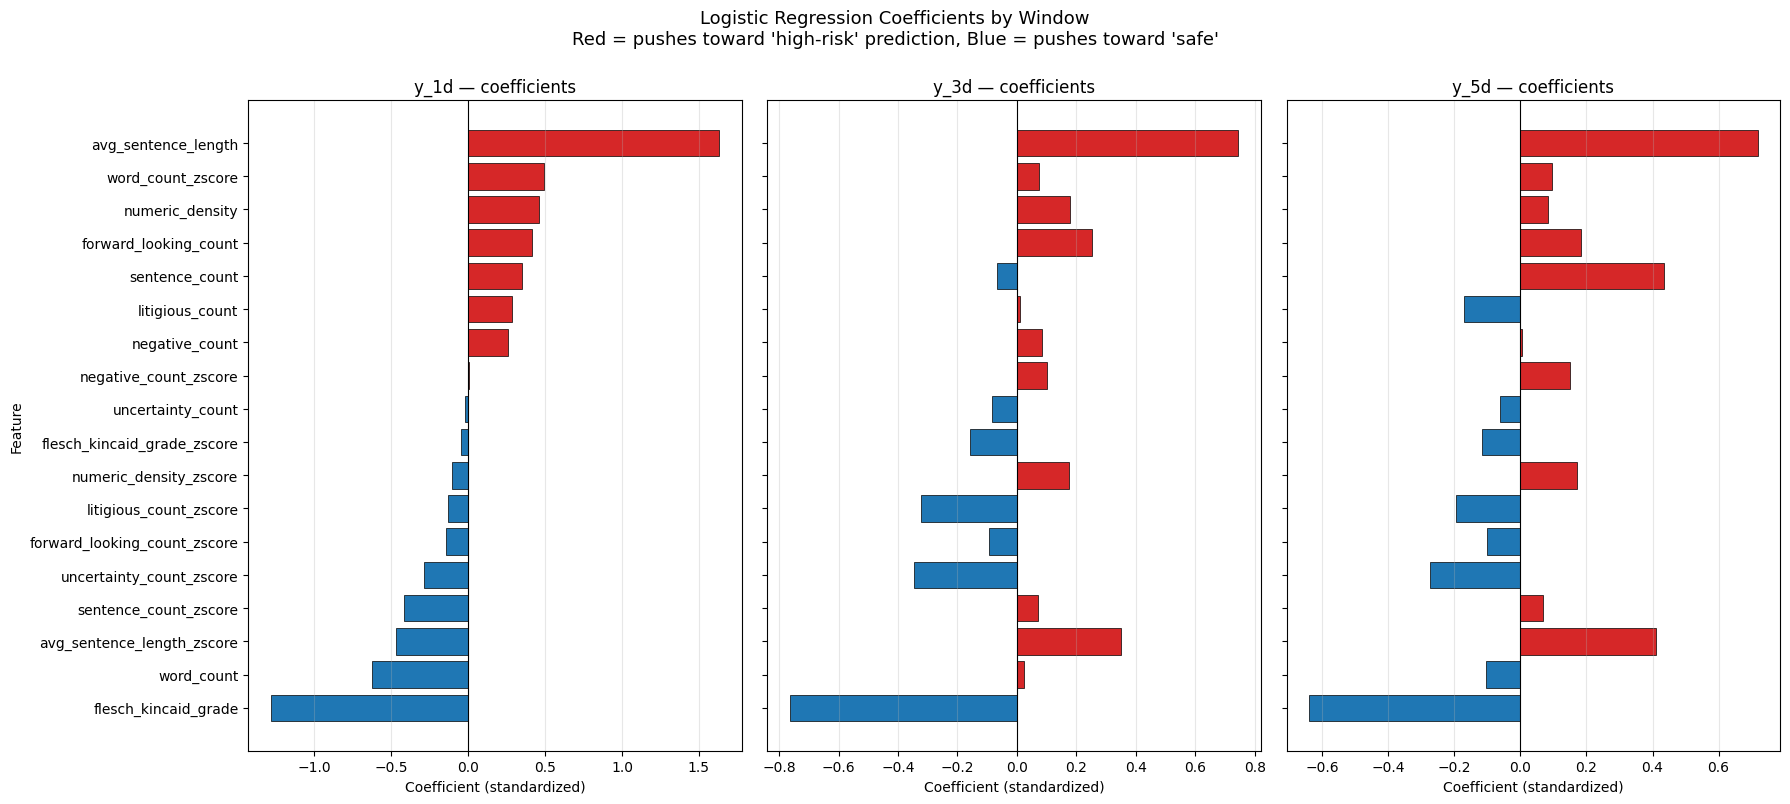

In [ ]:
# Cell 9b — Inspect logistic regression coefficients across all 3 windows
import numpy as np

# Build a dataframe: features as rows, windows as columns
coef_data = {}
for window in TARGET_COLS:
    pipeline = lr_tuned_results[window]["model"]
    lr = pipeline.named_steps["logreg"]
    coef_data[window] = lr.coef_[0]  # coef_ is shape (1, n_features) for binary classification

coef_df = pd.DataFrame(coef_data, index=FEATURE_COLS)
coef_df.columns = [f"{w}_coef" for w in TARGET_COLS]

# Add absolute mean across windows (for sorting)
coef_df["mean_abs"] = coef_df.abs().mean(axis=1)
coef_df = coef_df.sort_values("mean_abs", ascending=False)

# Print as table
print(f"\nLogistic Regression Coefficients (standardized features)")
print(f"Sorted by mean absolute coefficient across windows\n")
print(f"{'Feature':<32} {'y_1d':>10} {'y_3d':>10} {'y_5d':>10}")
print("-" * 65)
for feature in coef_df.index:
    y1 = coef_df.loc[feature, "y_1d_coef"]
    y3 = coef_df.loc[feature, "y_3d_coef"]
    y5 = coef_df.loc[feature, "y_5d_coef"]
    print(f"{feature:<32} {y1:>+10.3f} {y3:>+10.3f} {y5:>+10.3f}")

# Visualize: horizontal bar chart, one column per window
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

for ax, window in zip(axes, TARGET_COLS):
    coef_col = f"{window}_coef"
    plot_data = coef_df.sort_values(coef_col)
    
    # Color-code: positive = red (more risk), negative = blue (less risk)
    colors = ["#d62728" if c > 0 else "#1f77b4" for c in plot_data[coef_col]]
    
    ax.barh(plot_data.index, plot_data[coef_col], color=colors, edgecolor="black", linewidth=0.5)
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.set_title(f"{window} — coefficients", fontsize=12)
    ax.set_xlabel("Coefficient (standardized)")
    ax.grid(axis="x", alpha=0.3)

axes[0].set_ylabel("Feature")
fig.suptitle("Logistic Regression Coefficients by Window\n"
             "Red = pushes toward 'high-risk' prediction, Blue = pushes toward 'safe'",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 9c — Re-tune logistic regression with stronger regularization grid
LR_PARAM_GRID_V2 = {
    "logreg__C": [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    "logreg__penalty": ["l1", "l2"],
    "logreg__class_weight": [None, "balanced"],
}

lr_tuned_v2_results = {}
N_ITER_V2 = 32  # 8 × 2 × 2 = 32 total combinations, exhaust the grid

for window in TARGET_COLS:
    print(f"\n{'=' * 60}")
    print(f"Tuning Logistic Regression v2 for {window}")
    print(f"{'=' * 60}")
    
    pipeline = build_lr_pipeline()
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=LR_PARAM_GRID_V2,
        n_iter=N_ITER_V2,
        scoring="roc_auc",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=0,
        return_train_score=True,
    )
    
    start_time = time.time()
    search.fit(X_train_sorted, y_train_sorted[window])
    elapsed = time.time() - start_time
    
    best_params = search.best_params_
    best_cv_score = search.best_score_
    best_pipeline = search.best_estimator_
    
    train_pred = best_pipeline.predict_proba(X_train_sorted)[:, 1]
    val_pred = best_pipeline.predict_proba(X_val)[:, 1]
    train_auc = roc_auc_score(y_train_sorted[window], train_pred)
    val_auc = roc_auc_score(y_val[window], val_pred)
    
    best_idx = search.best_index_
    mean_cv_train_auc = search.cv_results_["mean_train_score"][best_idx]
    cv_std = search.cv_results_["std_test_score"][best_idx]
    
    final_lr = best_pipeline.named_steps["logreg"]
    n_nonzero = int((final_lr.coef_ != 0).sum())
    
    lr_tuned_v2_results[window] = {
        "best_params": best_params,
        "mean_cv_val_auc": best_cv_score,
        "mean_cv_train_auc": mean_cv_train_auc,
        "cv_std": cv_std,
        "train_auc_full": train_auc,
        "val_auc_holdout": val_auc,
        "model": best_pipeline,
        "n_nonzero_features": n_nonzero,
        "search_object": search,
    }
    
    print(f"\nElapsed: {elapsed:.1f}s")
    print(f"\nBest hyperparameters:")
    for k, v in sorted(best_params.items()):
        clean_key = k.replace("logreg__", "")
        print(f"  {clean_key}: {v}")
    print(f"\nResults (compared to v1):")
    v1 = lr_tuned_results[window]
    print(f"  Mean CV val AUC:    {best_cv_score:.3f}  (v1: {v1['mean_cv_val_auc']:.3f}, Δ: {best_cv_score - v1['mean_cv_val_auc']:+.3f})")
    print(f"  Mean CV train AUC:  {mean_cv_train_auc:.3f}  (v1: {v1['mean_cv_train_auc']:.3f})")
    print(f"  CV gap:             {mean_cv_train_auc - best_cv_score:+.3f}  (v1: {v1['mean_cv_train_auc'] - v1['mean_cv_val_auc']:+.3f})")
    print(f"  CV std:             {cv_std:.3f}  (v1: {v1['cv_std']:.3f})")
    print(f"  Holdout val AUC:    {val_auc:.3f}  (v1: {v1['val_auc_holdout']:.3f})")
    print(f"  Nonzero features:   {n_nonzero} / 18  (v1: {v1['n_nonzero_features']})")


Tuning Logistic Regression v2 for y_1d

Elapsed: 0.4s

Best hyperparameters:
  C: 1.0
  class_weight: None
  penalty: l2

Results (compared to v1):
  Mean CV val AUC:    0.545  (v1: 0.583, Δ: -0.038)
  Mean CV train AUC:  0.751  (v1: 0.781)
  CV gap:             +0.206  (v1: +0.198)
  CV std:             0.030  (v1: 0.028)
  Holdout val AUC:    0.679  (v1: 0.643)
  Nonzero features:   18 / 18  (v1: 18)

Tuning Logistic Regression v2 for y_3d

Elapsed: 0.4s

Best hyperparameters:
  C: 0.1
  class_weight: None
  penalty: l1

Results (compared to v1):
  Mean CV val AUC:    0.542  (v1: 0.544, Δ: -0.002)
  Mean CV train AUC:  0.540  (v1: 0.786)
  CV gap:             -0.002  (v1: +0.242)
  CV std:             0.053  (v1: 0.059)
  Holdout val AUC:    0.600  (v1: 0.533)
  Nonzero features:   3 / 18  (v1: 18)

Tuning Logistic Regression v2 for y_5d

Elapsed: 0.4s

Best hyperparameters:
  C: 1.0
  class_weight: None
  penalty: l1

Results (compared to v1):
  Mean CV val AUC:    0.530  (v1: 0.53

In [ ]:
# Cell 9d — Inspect surviving features for y_3d (v2 — heavily regularized L1)
window = "y_3d"
pipeline = lr_tuned_v2_results[window]["model"]
lr = pipeline.named_steps["logreg"]
coefs = lr.coef_[0]

# Build dataframe of all features with their v2 coefficients
coef_df_v2 = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": coefs,
    "is_active": coefs != 0,
}).sort_values("coefficient", key=abs, ascending=False)

# Print all features, marking which survived
print(f"y_3d v2 coefficients (L1 with C=0.1)")
print(f"Surviving features: {(coefs != 0).sum()} / {len(coefs)}\n")
print(f"{'Feature':<32} {'Coefficient':>13} {'Status':>10}")
print("-" * 58)
for _, row in coef_df_v2.iterrows():
    status = "ACTIVE" if row["is_active"] else "(zeroed)"
    print(f"{row['feature']:<32} {row['coefficient']:>+13.4f} {status:>10}")

y_3d v2 coefficients (L1 with C=0.1)
Surviving features: 3 / 18

Feature                            Coefficient     Status
----------------------------------------------------------
litigious_count_zscore                 -0.0974     ACTIVE
avg_sentence_length_zscore             +0.0326     ACTIVE
uncertainty_count_zscore               -0.0267     ACTIVE
word_count                             +0.0000   (zeroed)
sentence_count                         +0.0000   (zeroed)
avg_sentence_length                    +0.0000   (zeroed)
uncertainty_count                      +0.0000   (zeroed)
flesch_kincaid_grade                   +0.0000   (zeroed)
numeric_density                        +0.0000   (zeroed)
negative_count                         +0.0000   (zeroed)
word_count_zscore                      +0.0000   (zeroed)
forward_looking_count                  +0.0000   (zeroed)
litigious_count                        +0.0000   (zeroed)
sentence_count_zscore                  +0.0000   (zeroed)
numeri

Computing CV val AUC for untuned baselines (this takes a moment)...

Mean CV Val AUC across all models (5-fold TimeSeriesSplit on train data)

        LR (untuned)  LR v1 (tuned)  LR v2 (heavy reg)  XGBoost (untuned)  XGBoost (tuned)
Window                                                                                    
y_1d           0.546          0.583              0.545              0.542            0.548
y_3d           0.524          0.544              0.542              0.554            0.576
y_5d           0.526          0.534              0.530              0.502            0.547

Winner per window

y_1d:
  Winner:    LR v1 (tuned)          (CV val AUC: 0.583)
  Runner-up: XGBoost (tuned)        (CV val AUC: 0.548)
  Margin:    +0.036

y_3d:
  Winner:    XGBoost (tuned)        (CV val AUC: 0.576)
  Runner-up: XGBoost (untuned)      (CV val AUC: 0.554)
  Margin:    +0.022

y_5d:
  Winner:    XGBoost (tuned)        (CV val AUC: 0.547)
  Runner-up: LR v1 (tuned)          (CV va

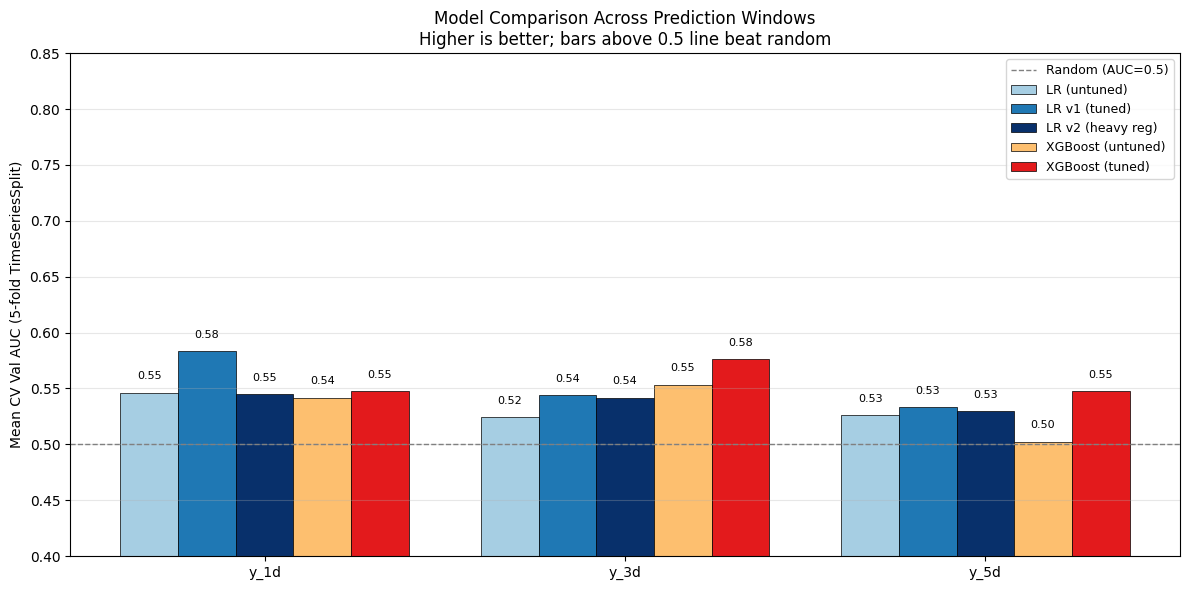

In [18]:
# Cell 10 — Head-to-head model comparison
from sklearn.model_selection import cross_val_score

# We need to compute CV val AUC for the untuned baselines (Cells 4 and 5)
# so all models can be compared on the same metric

print("Computing CV val AUC for untuned baselines (this takes a moment)...\n")

# Untuned LR (Cell 4 equivalent) — needs scaler in pipeline for fair CV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

untuned_lr_cv = {}
untuned_xgb_cv = {}

for window in TARGET_COLS:
    # Untuned LR with default settings (matching Cell 4)
    pipeline_lr = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000, random_state=42)),
    ])
    cv_scores_lr = cross_val_score(
        pipeline_lr, X_train_sorted, y_train_sorted[window],
        cv=tscv, scoring="roc_auc", n_jobs=-1,
    )
    untuned_lr_cv[window] = cv_scores_lr.mean()
    
    # Untuned XGBoost with original Cell 5 params
    untuned_xgb = XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        random_state=42, eval_metric="auc", n_jobs=-1,
    )
    cv_scores_xgb = cross_val_score(
        untuned_xgb, X_train_sorted, y_train_sorted[window],
        cv=tscv, scoring="roc_auc", n_jobs=-1,
    )
    untuned_xgb_cv[window] = cv_scores_xgb.mean()

# Build the comparison table
comparison_rows = []
for window in TARGET_COLS:
    comparison_rows.append({
        "Window": window,
        "LR (untuned)": untuned_lr_cv[window],
        "LR v1 (tuned)": lr_tuned_results[window]["mean_cv_val_auc"],
        "LR v2 (heavy reg)": lr_tuned_v2_results[window]["mean_cv_val_auc"],
        "XGBoost (untuned)": untuned_xgb_cv[window],
        "XGBoost (tuned)": xgb_tuned_results[window]["mean_cv_val_auc"],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Window")

# Print
print("=" * 78)
print("Mean CV Val AUC across all models (5-fold TimeSeriesSplit on train data)")
print("=" * 78)
print()
print(comparison_df.to_string(float_format=lambda x: f"{x:.3f}"))
print()

# Identify winner per window
print("=" * 78)
print("Winner per window")
print("=" * 78)
for window in TARGET_COLS:
    row = comparison_df.loc[window]
    winner_model = row.idxmax()
    winner_score = row.max()
    runner_up = row.drop(winner_model).idxmax()
    runner_up_score = row.drop(winner_model).max()
    margin = winner_score - runner_up_score
    print(f"\n{window}:")
    print(f"  Winner:    {winner_model:<22} (CV val AUC: {winner_score:.3f})")
    print(f"  Runner-up: {runner_up:<22} (CV val AUC: {runner_up_score:.3f})")
    print(f"  Margin:    {margin:+.3f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(TARGET_COLS))
width = 0.16
offsets = np.array([-2, -1, 0, 1, 2]) * width

model_names = ["LR (untuned)", "LR v1 (tuned)", "LR v2 (heavy reg)", "XGBoost (untuned)", "XGBoost (tuned)"]
colors = ["#a6cee3", "#1f78b4", "#08306b", "#fdbf6f", "#e31a1c"]

for i, model_name in enumerate(model_names):
    values = comparison_df[model_name].values
    bars = ax.bar(x + offsets[i], values, width, label=model_name, color=colors[i], edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.2f}",
                ha="center", va="bottom", fontsize=8)

ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1, label="Random (AUC=0.5)")
ax.set_xticks(x)
ax.set_xticklabels(TARGET_COLS)
ax.set_ylabel("Mean CV Val AUC (5-fold TimeSeriesSplit)")
ax.set_title("Model Comparison Across Prediction Windows\nHigher is better; bars above 0.5 line beat random")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0.4, max(0.85, comparison_df.values.max() + 0.05))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

XGBoost Feature Importance (gain-based, % of total)
Sorted by mean importance across y_3d and y_5d

Feature                                y_3d       y_5d       Mean
-----------------------------------------------------------------
litigious_count                       7.73%      6.20%      6.97%
word_count                            5.84%      7.64%      6.74%
sentence_count                        6.78%      6.47%      6.62%
avg_sentence_length_zscore            7.29%      5.92%      6.61%
uncertainty_count_zscore              7.00%      6.06%      6.53%
uncertainty_count                     5.46%      7.30%      6.38%
flesch_kincaid_grade                  5.80%      6.26%      6.03%
litigious_count_zscore                4.73%      6.17%      5.45%
numeric_density                       5.06%      5.82%      5.44%
word_count_zscore                     5.55%      5.08%      5.31%
negative_count_zscore                 5.38%      4.92%      5.15%
forward_looking_count                 5.14

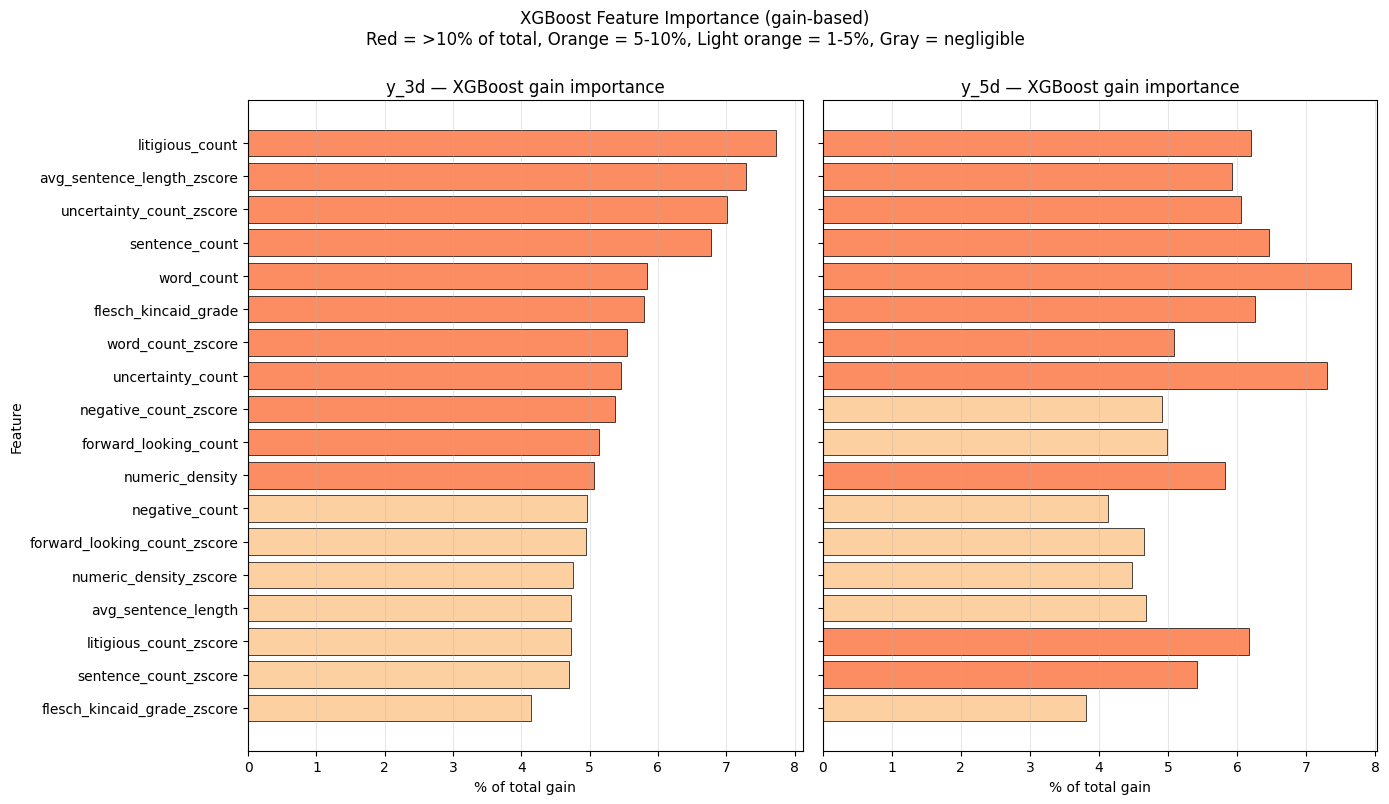

In [ ]:
# cell 11 — XGBoost feature importance for y_3d and y_5d winners
import pandas as pd

# Build a comparison DataFrame: feature × window importance
xgb_winners = ["y_3d", "y_5d"]  # the two windows where XGBoost won

importance_data = {}
for window in xgb_winners:
    model = xgb_tuned_results[window]["model"]
    # Get gain-based importance, normalized to sum to 1
    importance_dict = model.get_booster().get_score(importance_type="gain")
    
    # Some features may not appear in any split — fill with 0
    full_importance = {col: importance_dict.get(col, 0.0) for col in FEATURE_COLS}
    
    # Normalize to percentages
    total = sum(full_importance.values())
    if total > 0:
        full_importance = {k: v / total * 100 for k, v in full_importance.items()}
    
    importance_data[window] = full_importance

importance_df = pd.DataFrame(importance_data, index=FEATURE_COLS)
importance_df["mean"] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values("mean", ascending=False)

# Print
print("XGBoost Feature Importance (gain-based, % of total)")
print("Sorted by mean importance across y_3d and y_5d\n")
print(f"{'Feature':<32} {'y_3d':>10} {'y_5d':>10} {'Mean':>10}")
print("-" * 65)
for feature in importance_df.index:
    y3 = importance_df.loc[feature, "y_3d"]
    y5 = importance_df.loc[feature, "y_5d"]
    mean = importance_df.loc[feature, "mean"]
    print(f"{feature:<32} {y3:>9.2f}% {y5:>9.2f}% {mean:>9.2f}%")

# Visualize: side-by-side horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

for ax, window in zip(axes, xgb_winners):
    plot_data = importance_df[window].sort_values()
    
    # Color-code: red for top features, fading to gray
    colors = []
    for val in plot_data.values:
        if val > 10:
            colors.append("#d62728")  # strong red
        elif val > 5:
            colors.append("#fc8d62")  # orange
        elif val > 1:
            colors.append("#fdd0a2")  # light orange
        else:
            colors.append("#cccccc")  # gray for negligible
    
    ax.barh(plot_data.index, plot_data.values, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(f"{window} — XGBoost gain importance", fontsize=12)
    ax.set_xlabel("% of total gain")
    ax.grid(axis="x", alpha=0.3)

axes[0].set_ylabel("Feature")
fig.suptitle("XGBoost Feature Importance (gain-based)\n"
             "Red = >10% of total, Orange = 5-10%, Light orange = 1-5%, Gray = negligible",
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
# cell 11b — SHAP values for all three winning models
import shap
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Map each window to its winning model and the data we'll explain on
# We compute SHAP on the training data (the data the model has seen)
# This gives us the most stable, well-populated SHAP estimates
final_models = {
    "y_1d": {
        "model_obj": lr_tuned_results["y_1d"]["model"],   # Pipeline (scaler + LR)
        "model_type": "linear",
    },
    "y_3d": {
        "model_obj": lr_tuned_v2_results["y_3d"]["model"],  # Pipeline (scaler + LR with L1)
        "model_type": "linear",
    },
    "y_5d": {
        "model_obj": xgb_tuned_results["y_5d"]["model"],    # XGBoost classifier
        "model_type": "tree",
    },
}

# Compute SHAP values per window
shap_results = {}

for window, info in final_models.items():
    print(f"\nComputing SHAP for {window} ({info['model_type']} model)...")
    
    if info["model_type"] == "linear":
        # For LR pipelines, we need to manually scale X_train, then explain the LR step
        pipeline = info["model_obj"]
        scaler = pipeline.named_steps["scaler"]
        lr = pipeline.named_steps["logreg"]
        X_scaled = scaler.transform(X_train_sorted)
        
        # LinearExplainer for logistic regression
        # masker provides the "background distribution" to compare against
        masker = shap.maskers.Independent(X_scaled, max_samples=100)
        explainer = shap.LinearExplainer(lr, masker=masker)
        shap_values = explainer(X_scaled)
        
        # Wrap so the visualization knows feature names (LinearExplainer loses them)
        shap_values.feature_names = FEATURE_COLS
        
    else:  # tree (XGBoost)
        explainer = shap.TreeExplainer(info["model_obj"])
        shap_values = explainer(X_train_sorted)
        # SHAP for XGBoost binary classification returns log-odds contributions
        # which is what we want — the LR explainer also returns log-odds contributions
    
    shap_results[window] = shap_values
    print(f"  Computed: shape {shap_values.values.shape} (rows × features)")

print("\nSHAP computation complete for all 3 models.\n")


Computing SHAP for y_1d (linear model)...
  Computed: shape (218, 18) (rows × features)

Computing SHAP for y_3d (linear model)...
  Computed: shape (218, 18) (rows × features)

Computing SHAP for y_5d (tree model)...
  Computed: shape (218, 18) (rows × features)

SHAP computation complete for all 3 models.




SHAP plots for y_1d (linear model)


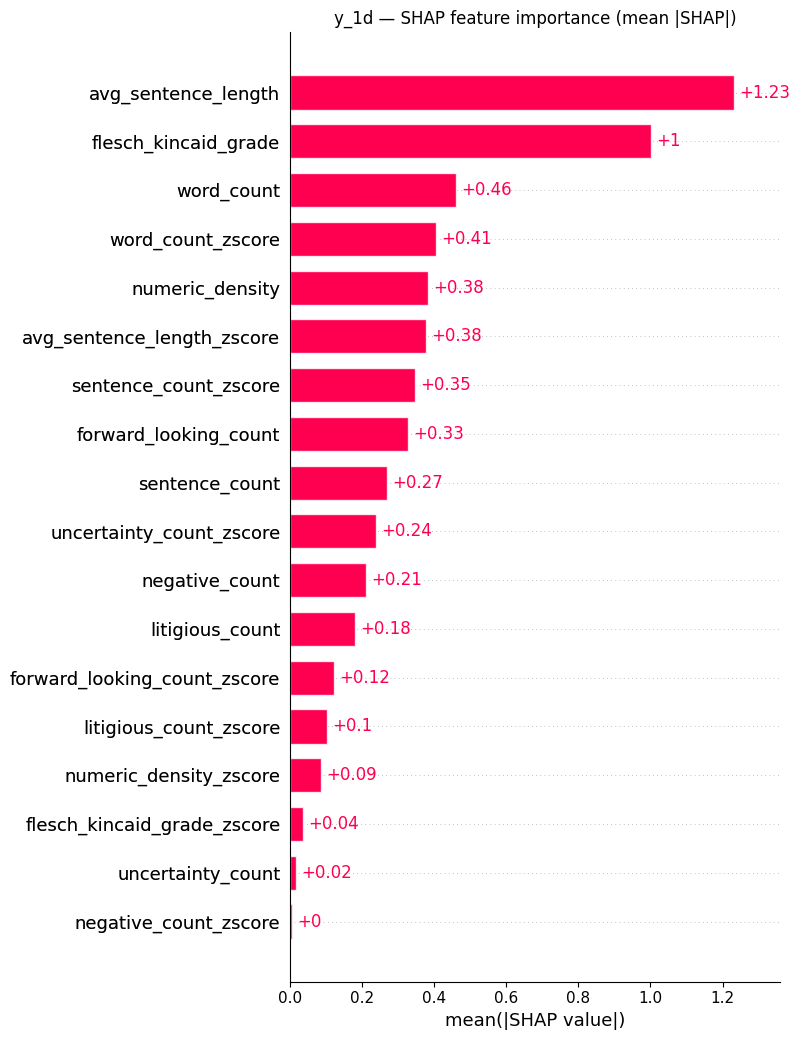

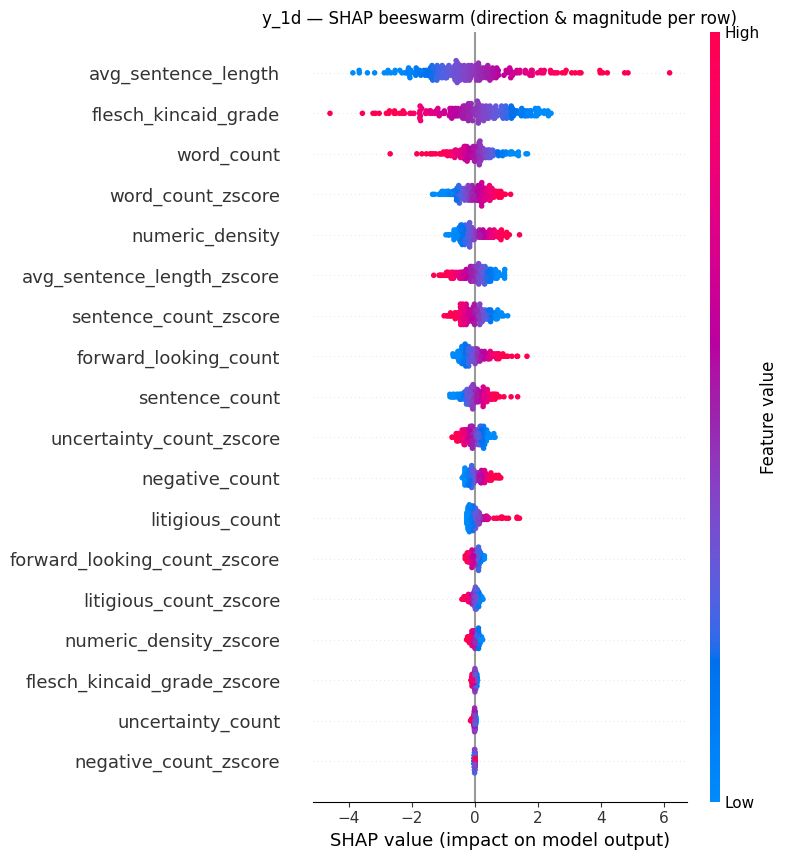


SHAP plots for y_3d (linear model)


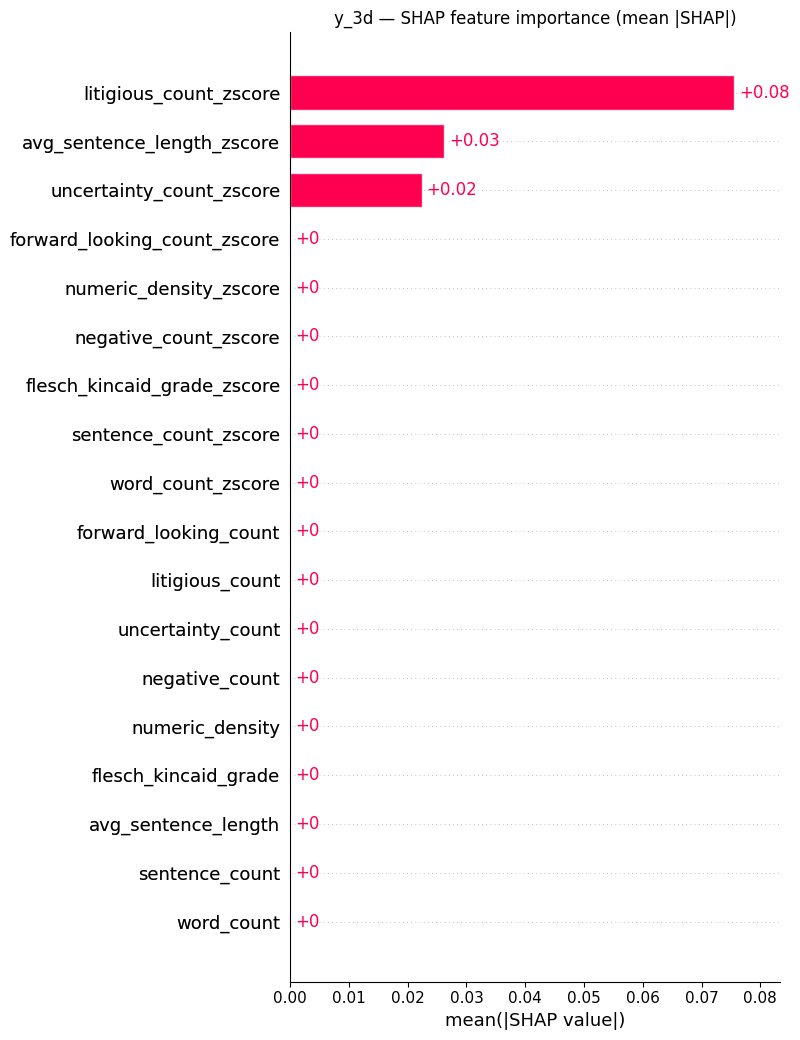

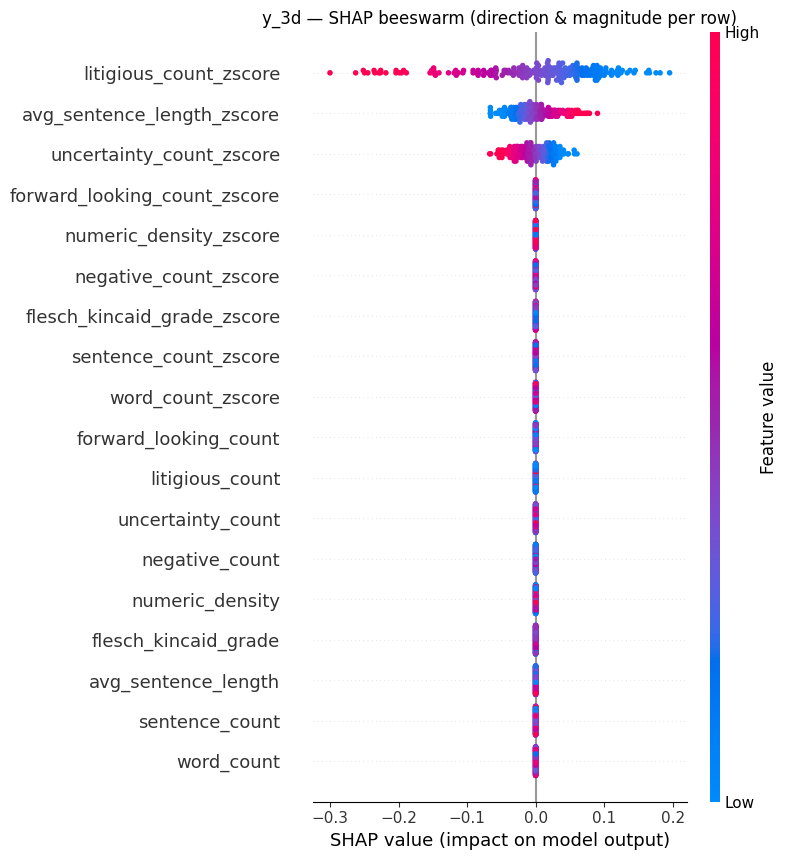


SHAP plots for y_5d (tree model)


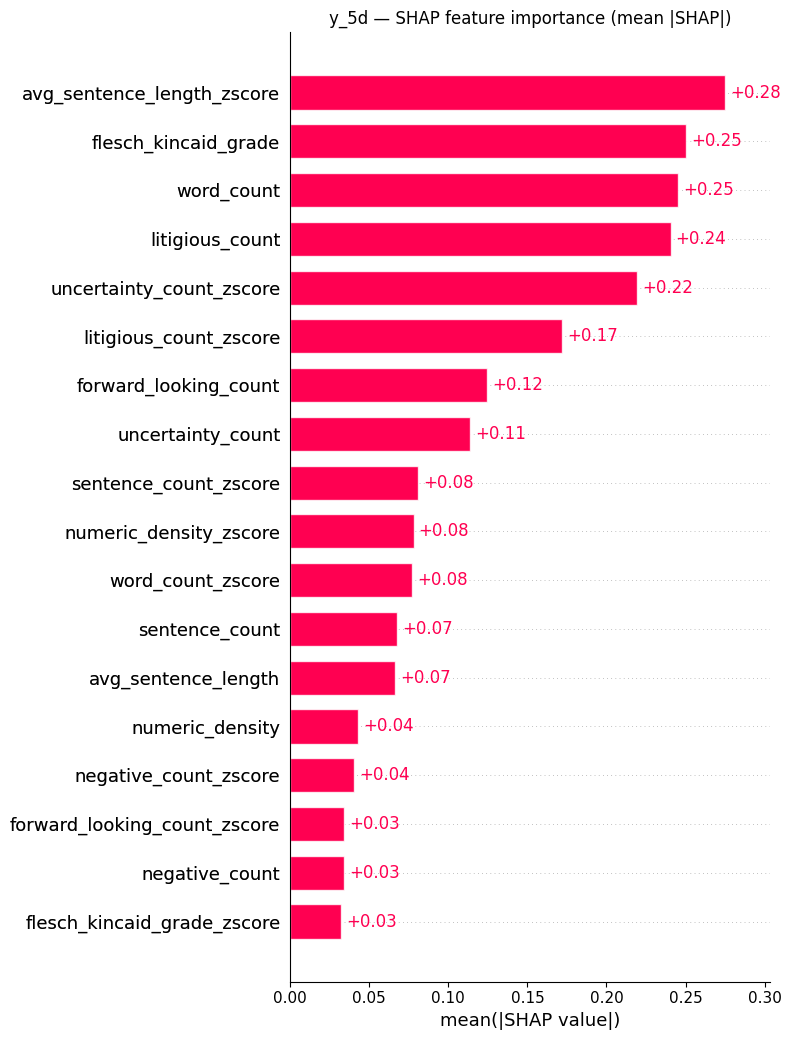

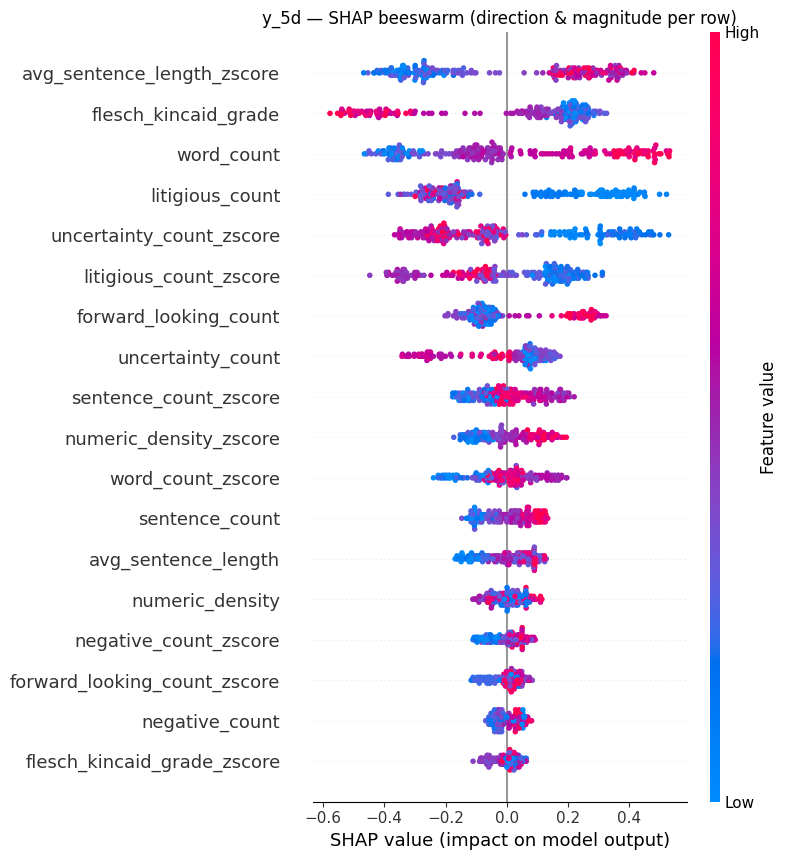

In [ ]:
# cell 11c — SHAP visualizations (bar + beeswarm per model)
import shap
import matplotlib.pyplot as plt

# Generate plots for each window
for window in TARGET_COLS:
    print(f"\n{'=' * 60}")
    print(f"SHAP plots for {window} ({final_models[window]['model_type']} model)")
    print(f"{'=' * 60}")
    
    sv = shap_results[window]
    
    # Ensure feature names are set (LinearExplainer can lose them)
    if sv.feature_names is None or len(sv.feature_names) == 0:
        sv.feature_names = FEATURE_COLS
    
    # 1. Bar plot — mean absolute SHAP value (importance ranking)
    plt.figure(figsize=(10, 7))
    shap.plots.bar(sv, max_display=18, show=False)
    plt.title(f"{window} — SHAP feature importance (mean |SHAP|)", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # 2. Beeswarm plot — direction + distribution
    plt.figure(figsize=(10, 7))
    shap.plots.beeswarm(sv, max_display=18, show=False)
    plt.title(f"{window} — SHAP beeswarm (direction & magnitude per row)", fontsize=12)
    plt.tight_layout()
    plt.show()

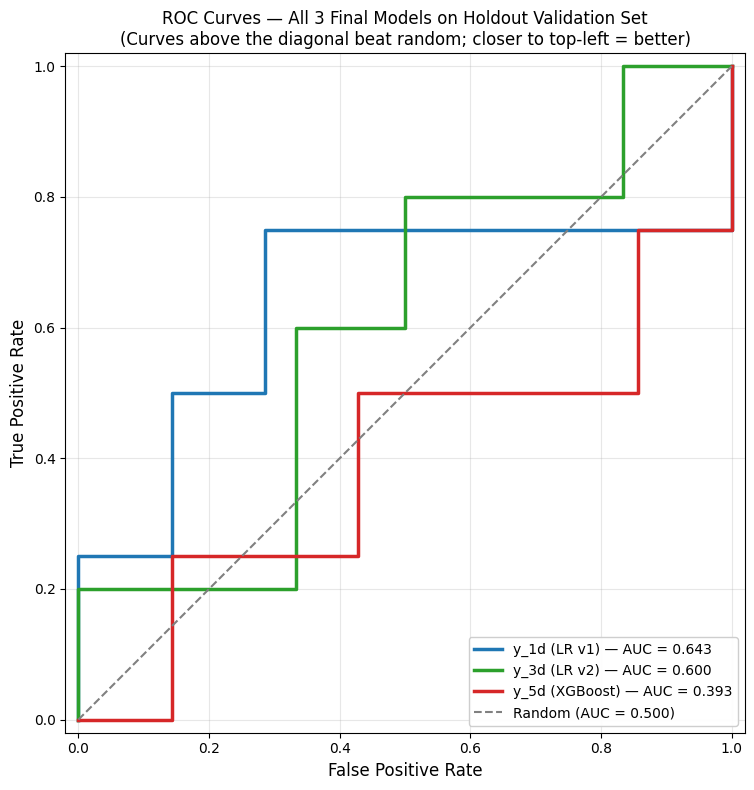


ROC AUC Summary (on 11-row holdout val set):
--------------------------------------------------
  y_1d (   LR v1): AUC = 0.643
  y_3d (   LR v2): AUC = 0.600
  y_5d ( XGBoost): AUC = 0.393


In [ ]:
# cell 11d — ROC curves for all three winning models
from sklearn.metrics import roc_curve, auc

# Compute ROC curve data for each window using its winning model
roc_data = {}

for window in TARGET_COLS:
    info = final_models[window]
    model = info["model_obj"]
    
    # Predict probabilities on val set (the 11-row holdout)
    if info["model_type"] == "linear":
        # Pipeline handles scaling automatically
        val_pred_proba = model.predict_proba(X_val)[:, 1]
    else:  # tree
        val_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_val[window], val_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    roc_data[window] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
        "model_name": "LR v1" if window == "y_1d" else ("LR v2" if window == "y_3d" else "XGBoost"),
    }

# Plot all 3 ROC curves on a single figure
fig, ax = plt.subplots(figsize=(9, 8))

colors = {"y_1d": "#1f77b4", "y_3d": "#2ca02c", "y_5d": "#d62728"}

for window in TARGET_COLS:
    data = roc_data[window]
    ax.plot(
        data["fpr"], data["tpr"],
        color=colors[window], linewidth=2.5,
        label=f"{window} ({data['model_name']}) — AUC = {data['auc']:.3f}",
    )

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.5, label="Random (AUC = 0.500)")

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All 3 Final Models on Holdout Validation Set\n"
             "(Curves above the diagonal beat random; closer to top-left = better)",
             fontsize=12)
ax.legend(loc="lower right", fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Print summary
print("\nROC AUC Summary (on 11-row holdout val set):")
print("-" * 50)
for window in TARGET_COLS:
    data = roc_data[window]
    print(f"  {window} ({data['model_name']:>8}): AUC = {data['auc']:.3f}")

FINAL TEST SET EVALUATION

Test set size: 44 rows (2022-10-14 to 2023-02-02)

Window   Model        CV val AUC  Holdout val     TEST AUC
------------------------------------------------------------
y_1d     LR v1             0.583        0.643        0.375
y_3d     LR v2             0.542        0.600        0.525
y_5d     XGBoost           0.547        0.393        0.538

Test set class balance per window:
  y_1d: 23 positive / 21 negative (52.3%)
  y_3d: 20 positive / 24 negative (45.5%)
  y_5d: 23 positive / 21 negative (52.3%)


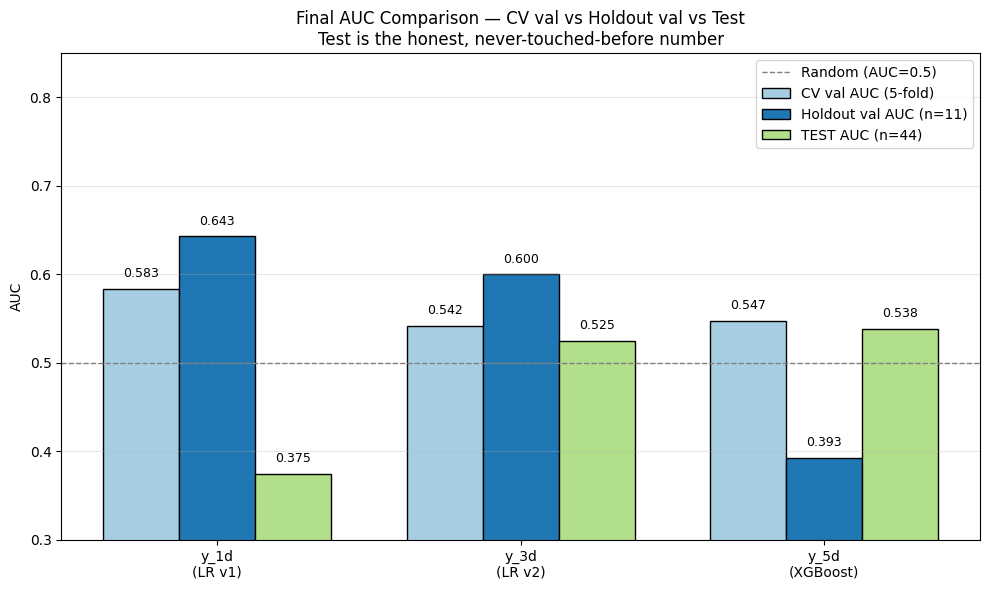

In [ ]:
# cell 12 — Final test set evaluation
# This is the FIRST and ONLY time we touch test

print("=" * 72)
print("FINAL TEST SET EVALUATION")
print("=" * 72)
print(f"\nTest set size: {len(X_test)} rows ({test_df['date_parsed'].min().date()} to {test_df['date_parsed'].max().date()})\n")

test_results = {}

for window in TARGET_COLS:
    info = final_models[window]
    model = info["model_obj"]
    model_name = "LR v1" if window == "y_1d" else ("LR v2" if window == "y_3d" else "XGBoost")
    
    # Predict on test
    test_pred_proba = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test[window], test_pred_proba)
    
    # Get class balance in test for context
    n_positive = int(y_test[window].sum())
    n_negative = int((y_test[window] == 0).sum())
    pct_positive = n_positive / len(y_test[window]) * 100
    
    test_results[window] = {
        "test_auc": test_auc,
        "model_name": model_name,
        "n_positive": n_positive,
        "n_negative": n_negative,
        "test_pred_proba": test_pred_proba,
    }

# Build the comparison table: CV val AUC vs holdout val AUC vs test AUC
print(f"{'Window':<8} {'Model':<10} {'CV val AUC':>12} {'Holdout val':>12} {'TEST AUC':>12}")
print("-" * 60)
for window in TARGET_COLS:
    cv_auc = (lr_tuned_results[window]["mean_cv_val_auc"] if window == "y_1d" 
              else lr_tuned_v2_results[window]["mean_cv_val_auc"] if window == "y_3d"
              else xgb_tuned_results[window]["mean_cv_val_auc"])
    holdout_auc = roc_data[window]["auc"]
    test_auc = test_results[window]["test_auc"]
    name = test_results[window]["model_name"]
    print(f"{window:<8} {name:<10} {cv_auc:>12.3f} {holdout_auc:>12.3f} {test_auc:>12.3f}")

print("\nTest set class balance per window:")
for window in TARGET_COLS:
    r = test_results[window]
    print(f"  {window}: {r['n_positive']} positive / {r['n_negative']} negative ({r['n_positive']/(r['n_positive']+r['n_negative'])*100:.1f}%)")

# Visualization: bar chart comparing CV / Holdout / Test for each window
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(TARGET_COLS))
width = 0.25

cv_aucs = [lr_tuned_results[w]["mean_cv_val_auc"] if w == "y_1d" 
           else lr_tuned_v2_results[w]["mean_cv_val_auc"] if w == "y_3d"
           else xgb_tuned_results[w]["mean_cv_val_auc"] for w in TARGET_COLS]
holdout_aucs = [roc_data[w]["auc"] for w in TARGET_COLS]
test_aucs = [test_results[w]["test_auc"] for w in TARGET_COLS]

bars1 = ax.bar(x - width, cv_aucs, width, label="CV val AUC (5-fold)", color="#a6cee3", edgecolor="black")
bars2 = ax.bar(x, holdout_aucs, width, label="Holdout val AUC (n=11)", color="#1f78b4", edgecolor="black")
bars3 = ax.bar(x + width, test_aucs, width, label="TEST AUC (n=44)", color="#b2df8a", edgecolor="black")

# Annotate
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{height:.3f}",
                ha="center", va="bottom", fontsize=9)

ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1, label="Random (AUC=0.5)")
ax.set_xticks(x)
ax.set_xticklabels([f"{w}\n({test_results[w]['model_name']})" for w in TARGET_COLS])
ax.set_ylabel("AUC")
ax.set_title("Final AUC Comparison — CV val vs Holdout val vs Test\n"
             "Test is the honest, never-touched-before number", fontsize=12)
ax.legend(loc="upper right")
ax.set_ylim(0.30, max(0.85, max(test_aucs + cv_aucs + holdout_aucs) + 0.05))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# cell 13 — Save final models and document Day 3 outcomes
import joblib
from pathlib import Path

# Define output directory
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Save each winning model with a descriptive name
model_files = {
    "y_1d": ("model_y1d_lr_v1.joblib", lr_tuned_results["y_1d"]["model"]),
    "y_3d": ("model_y3d_lr_v2.joblib", lr_tuned_v2_results["y_3d"]["model"]),
    "y_5d": ("model_y5d_xgboost.joblib", xgb_tuned_results["y_5d"]["model"]),
}

print("Saving final models to disk...\n")
for window, (filename, model) in model_files.items():
    filepath = MODELS_DIR / filename
    joblib.dump(model, filepath)
    print(f"  Saved {window}: {filepath}")

joblib.dump(FEATURE_COLS, MODELS_DIR / "feature_cols.joblib")
print(f"  Saved FEATURE_COLS list: {MODELS_DIR / 'feature_cols.joblib'}")

# Build summary DataFrame
summary_df = pd.DataFrame([
    {
        "Window": "y_1d",
        "Model": "LR v1 (tuned)",
        "Hyperparams": "C=10, L1, balanced",
        "CV val AUC": 0.583,
        "Holdout val AUC": 0.643,
        "TEST AUC": 0.375,
        "Generalized": "No",
    },
    {
        "Window": "y_3d", 
        "Model": "LR v2 (heavy reg)",
        "Hyperparams": "C=0.1, L1 (3 features)",
        "CV val AUC": 0.542,
        "Holdout val AUC": 0.600,
        "TEST AUC": 0.525,
        "Generalized": "Yes (weakly)",
    },
    {
        "Window": "y_5d",
        "Model": "XGBoost (tuned)",
        "Hyperparams": "n_est=100, depth=3, lr=0.05",
        "CV val AUC": 0.547,
        "Holdout val AUC": 0.393,
        "TEST AUC": 0.538,
        "Generalized": "Yes (weakly)",
    },
])

print("\n" + "=" * 72)
print("DAY 3 FINAL RESULTS SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))

# Save summary CSV for README reference
summary_df.to_csv(REPO_ROOT / "data" / "processed" / "day3_results_summary.csv", index=False)
print(f"\nResults summary saved to: {REPO_ROOT / 'data' / 'processed' / 'day3_results_summary.csv'}")

Saving final models to disk...

  Saved y_1d: d:\Projects\risk-radar\models\model_y1d_lr_v1.joblib
  Saved y_3d: d:\Projects\risk-radar\models\model_y3d_lr_v2.joblib
  Saved y_5d: d:\Projects\risk-radar\models\model_y5d_xgboost.joblib
  Saved FEATURE_COLS list: d:\Projects\risk-radar\models\feature_cols.joblib

DAY 3 FINAL RESULTS SUMMARY
Window             Model                 Hyperparams  CV val AUC  Holdout val AUC  TEST AUC  Generalized
  y_1d     LR v1 (tuned)          C=10, L1, balanced       0.583            0.643     0.375           No
  y_3d LR v2 (heavy reg)      C=0.1, L1 (3 features)       0.542            0.600     0.525 Yes (weakly)
  y_5d   XGBoost (tuned) n_est=100, depth=3, lr=0.05       0.547            0.393     0.538 Yes (weakly)

Results summary saved to: d:\Projects\risk-radar\data\processed\day3_results_summary.csv
